# 55230316 - DroneVehicle 多模态目标检测基线研究

## 1. EDA（探索性数据分析）& 2. 轻量级基线模型构建

**目标**: 为无人机俯视下的 RGB-Thermal 多模态车辆检测建立基线，并用于后续模型优化的对比。

---

In [ ]:
## Part 0: 环境准备与导入

### 路径配置（所有路径使用相对路径）
from pathlib import Path
NOTEBOOK_DIR = Path.cwd()  # Notebook 所在目录
PROJECT_ROOT = NOTEBOOK_DIR.parent  # 项目根目录（智能算法综合实践）
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'DroneVehicle'
# DATASET_ROOT = Path('/home/tyr/datasets/DroneVehicle')  # 数据集根目录
FIGURES_DIR = NOTEBOOK_DIR / 'figures'  # 图片保存目录

# 创建 figures 目录
FIGURES_DIR.mkdir(exist_ok=True)

# 验证路径
print(f"项目根目录：{PROJECT_ROOT}")
print(f"数据集根目录：{DATASET_ROOT}")
print(f"图片保存目录：{FIGURES_DIR}")

### 导入库
import os

import sys

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from PIL import Image

import xml.etree.ElementTree as ET

from pathlib import Path

import cv2

from collections import defaultdict, Counter

import warnings

import matplotlib.pyplot as plt

import matplotlib

import torch

import torch.nn as nn

import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

from torchvision.models import resnet18, resnet50


# 设置中文字体
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'DejaVu Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 深度学习框架
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnet50

print(f"\nPyTorch 版本：{torch.__version__}")
print(f"CUDA 可用：{torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


项目根目录：/home/tyr/ultralytics
数据集根目录：/home/tyr/datasets/DroneVehicle
图片保存目录：/home/tyr/ultralytics/figures

PyTorch 版本：2.10.0+cu128
CUDA 可用：True
GPU: NVIDIA A100-SXM4-80GB


## Part 1: 数据集路径配置与基本统计

In [75]:
# 数据集各分割路径
data_splits = {
    'train': DATASET_ROOT / 'train',
    'val': DATASET_ROOT / 'val',
    'test': DATASET_ROOT / 'test'
}

# 验证路径存在
for split, path in data_splits.items():
    if path.exists():
        print(f"✓ {split}: {path}")
    else:
        print(f"✗ {split}: 路径不存在")


✓ train: /home/tyr/datasets/DroneVehicle/train
✓ val: /home/tyr/datasets/DroneVehicle/val
✓ test: /home/tyr/datasets/DroneVehicle/test


In [76]:
def count_files_in_split(split_path, pattern):
    """统计特定分割中的文件数量"""
    if not split_path.exists():
        return 0
    count = 0
    for root, dirs, files in os.walk(split_path):
        count += sum(1 for f in files if f.endswith(pattern))
    return count

# 统计数据量
dataset_stats = {}
for split, path in data_splits.items():
    rgb_count = count_files_in_split(path / 'trainimg' if split == 'train' else path / f'{split}img', '.jpg')
    thermal_count = count_files_in_split(path / 'trainimgr' if split == 'train' else path / f'{split}imgr', '.jpg')
    label_count = count_files_in_split(path / 'trainlabel' if split == 'train' else path / f'{split}label', '.xml')
    
    dataset_stats[split] = {
        'RGB': rgb_count,
        'Thermal': thermal_count,
        'Labels': label_count
    }

df_stats = pd.DataFrame(dataset_stats).T
print("\n数据集统计信息:")
print(df_stats)
print(f"\n总样本数: {df_stats['RGB'].sum()}")


数据集统计信息:
         RGB  Thermal  Labels
train  17990    17990   17990
val     1469     1469    1469
test    8980     8980    8980

总样本数: 28439


## Part 2: EDA - 标签解析与目标类别分析

In [77]:
def parse_xml_annotation(xml_path):
    """解析 XML 标注文件，提取目标信息"""
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # 图像尺寸
        size = root.find('size')
        width = int(size.find('width').text)
        height = int(size.find('height').text)
        
        objects = []
        for obj in root.findall('object'):
            name = obj.find('name').text
            polygon = obj.find('polygon')
            
            if polygon is not None:
                xs = [int(polygon.find(f'x{i}').text) for i in range(1, 5)]
                ys = [int(polygon.find(f'y{i}').text) for i in range(1, 5)]
                
                # 转换为 bbox (xmin, ymin, xmax, ymax)
                xmin, xmax = min(xs), max(xs)
                ymin, ymax = min(ys), max(ys)
                
                # 计算面积
                area = (xmax - xmin) * (ymax - ymin)
                
                objects.append({
                    'class': name,
                    'bbox': [xmin, ymin, xmax, ymax],
                    'area': area,
                    'width': xmax - xmin,
                    'height': ymax - ymin
                })
        
        return {
            'image_width': width,
            'image_height': height,
            'objects': objects
        }
    except Exception as e:
        print(f"Error parsing {xml_path}: {e}")
        return None

# 测试解析
test_xml = list((DATASET_ROOT / 'train' / 'trainlabel').glob('*.xml'))[0]
sample_annotation = parse_xml_annotation(test_xml)
print(f"样本标注: {test_xml.name}")
print(f"图像尺寸: {sample_annotation['image_width']} x {sample_annotation['image_height']}")
print(f"目标数: {len(sample_annotation['objects'])}")
print(f"\n前 3 个目标:")
for i, obj in enumerate(sample_annotation['objects'][:3]):
    print(f"  {i+1}. {obj['class']}: area={obj['area']}, bbox={obj['bbox']}")

样本标注: 17248.xml
图像尺寸: 840 x 712
目标数: 3

前 3 个目标:
  1. car: area=2640, bbox=[545, 436, 589, 496]
  2. car: area=3922, bbox=[567, 508, 620, 582]
  3. car: area=2376, bbox=[592, 580, 636, 634]


In [78]:
# 全量解析训练集标注（用于 EDA）
print("正在解析训练集标注...")

train_label_dir = DATASET_ROOT / 'train' / 'trainlabel'
class_counts = Counter()
area_stats = defaultdict(list)
obj_count_per_image = []
image_size_data = []

for xml_file in sorted(train_label_dir.glob('*.xml')):
    anno = parse_xml_annotation(xml_file)
    if anno is None:
        continue
    
    obj_count_per_image.append(len(anno['objects']))
    image_size_data.append((anno['image_width'], anno['image_height']))
    
    for obj in anno['objects']:
        class_counts[obj['class']] += 1
        area_stats[obj['class']].append(obj['area'])

print(f"✓ 共解析 {len(obj_count_per_image)} 个图像")
print(f"\n目标类别及数量:")
for cls, count in class_counts.most_common():
    print(f"  {cls}: {count}")

print(f"\n总目标数: {sum(class_counts.values())}")

正在解析训练集标注...
✓ 共解析 17990 个图像

目标类别及数量:
  car: 226974
  truck: 13056
  bus: 9988
  van: 7208
  feright_car: 5337
  feright car: 2721
  feright: 1
  *: 1
  truvk: 1

总目标数: 265287


## Part 3: EDA - 可视化分析

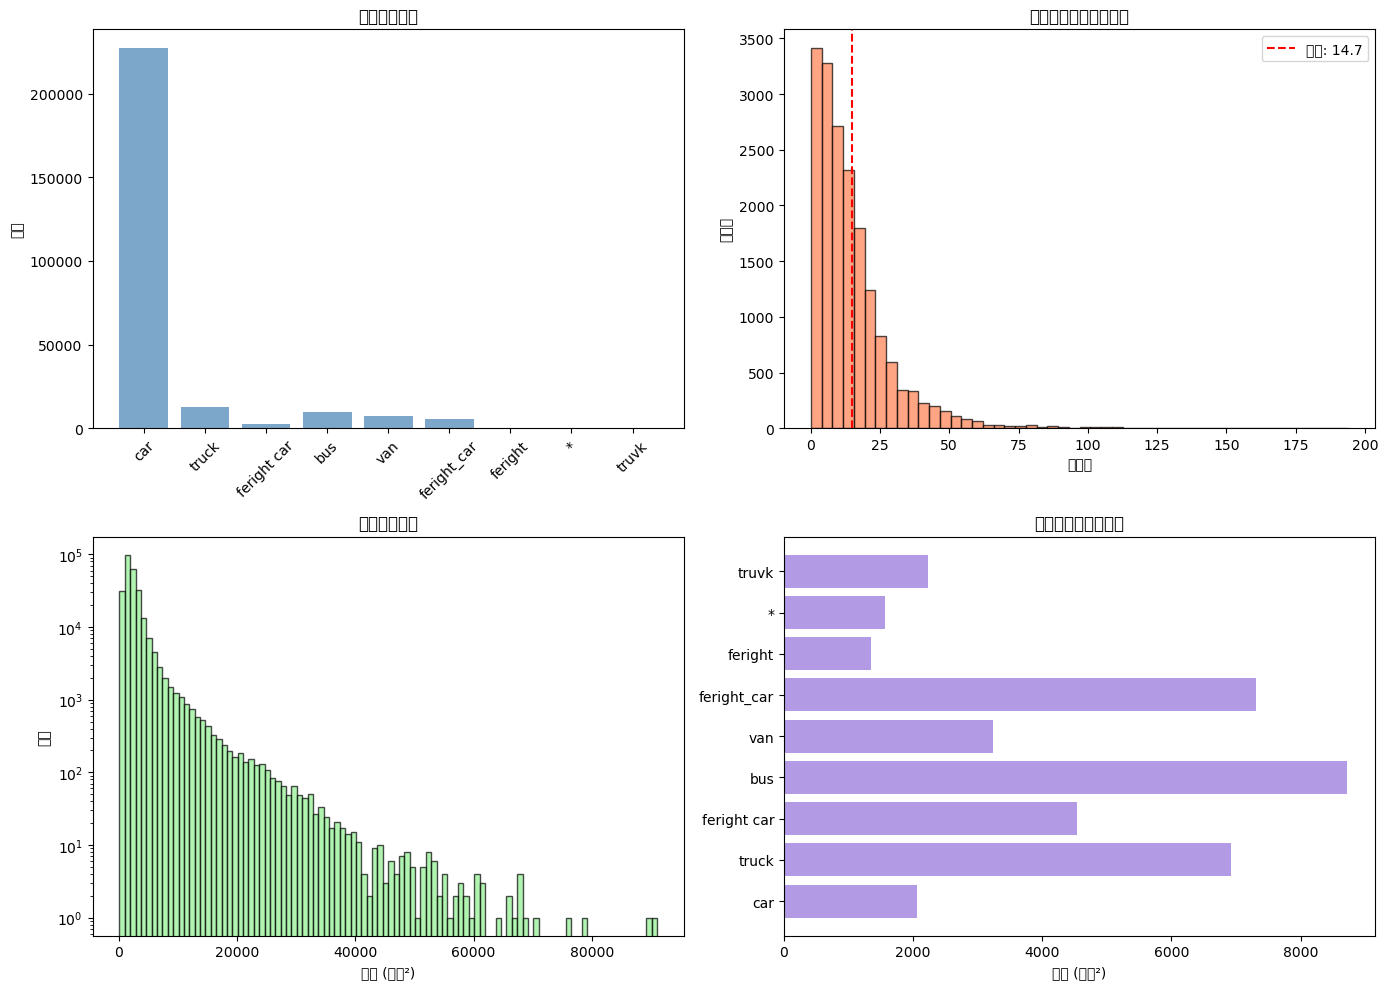

EDA 可视化已保存


In [79]:
# 1. 目标类别分布
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 类别分布
classes = list(class_counts.keys())
counts = list(class_counts.values())
axes[0, 0].bar(classes, counts, color='steelblue', alpha=0.7)
axes[0, 0].set_title('目标类别分布', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('数量')
axes[0, 0].tick_params(axis='x', rotation=45)

# 每张图像的目标数分布
axes[0, 1].hist(obj_count_per_image, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('每张图像的目标数分布', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('目标数')
axes[0, 1].set_ylabel('图像数')
axes[0, 1].axvline(np.mean(obj_count_per_image), color='red', linestyle='--', label=f'均值: {np.mean(obj_count_per_image):.1f}')
axes[0, 1].legend()

# 目标面积分布（对数尺度）
all_areas = []
for areas in area_stats.values():
    all_areas.extend(areas)

axes[1, 0].hist(all_areas, bins=100, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('目标面积分布', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('面积 (像素²)')
axes[1, 0].set_ylabel('频数')
axes[1, 0].set_yscale('log')

# 不同类别的平均面积
avg_areas = {cls: np.mean(area_stats[cls]) for cls in class_counts.keys()}
axes[1, 1].barh(list(avg_areas.keys()), list(avg_areas.values()), color='mediumpurple', alpha=0.7)
axes[1, 1].set_title('各类别平均目标面积', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('面积 (像素²)')

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'eda_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("EDA 可视化已保存")

In [80]:
# 小目标分析（< 32x32）
print("\n小目标分析 (<32x32 像素):")
small_target_count = sum(1 for obj in [o for objs in area_stats.values() for o in objs] 
                         if obj <= 32*32)
total_targets = len(all_areas)
small_target_ratio = small_target_count / total_targets * 100

print(f"  小目标总数: {small_target_count}")
print(f"  占比: {small_target_ratio:.2f}%")
print(f"\n目标面积统计:")
print(f"  最小: {min(all_areas):.0f} 像素²")
print(f"  最大: {max(all_areas):.0f} 像素²")
print(f"  中位数: {np.median(all_areas):.0f} 像素²")
print(f"  平均: {np.mean(all_areas):.0f} 像素²")


小目标分析 (<32x32 像素):
  小目标总数: 31576
  占比: 11.90%

目标面积统计:
  最小: 110 像素²
  最大: 91008 像素²
  中位数: 1960 像素²
  平均: 2719 像素²


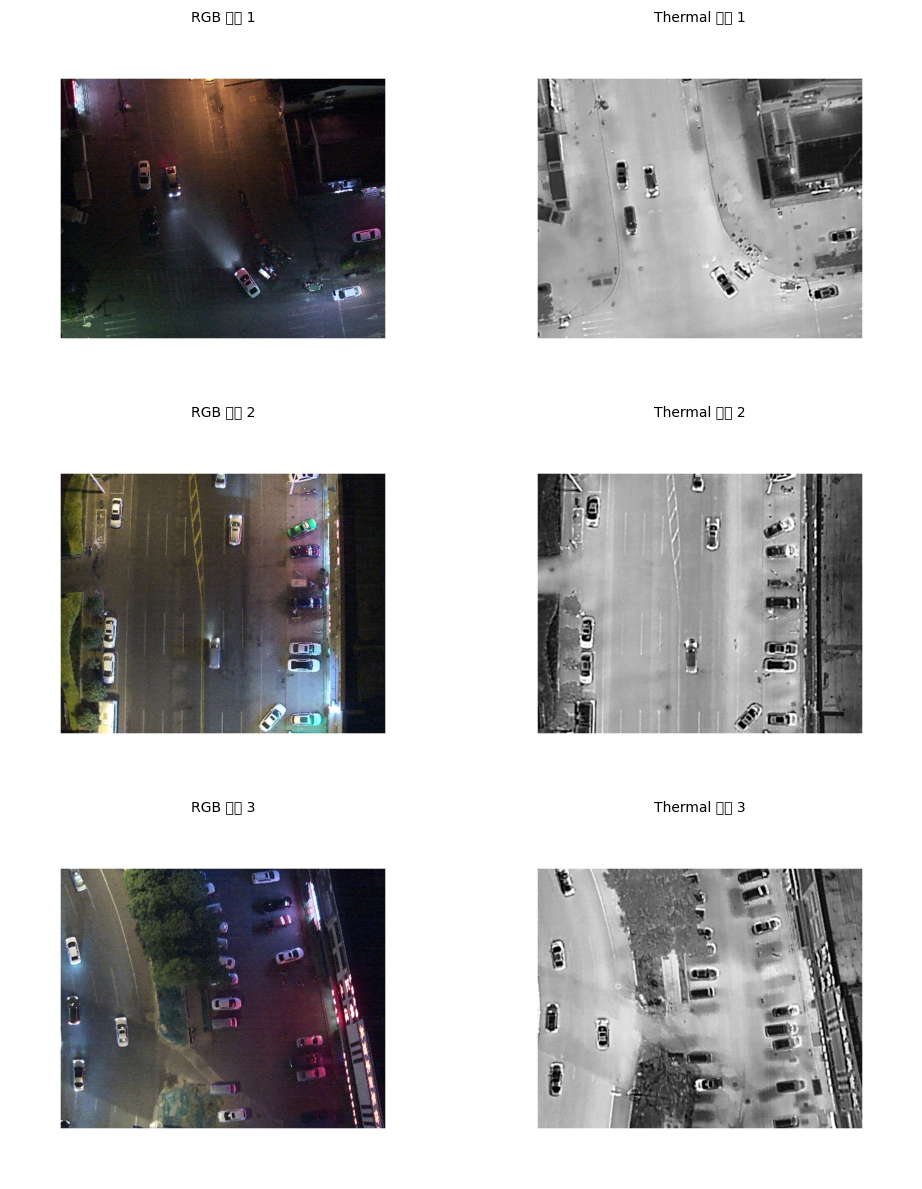

RGB-Thermal 样本已保存


In [81]:
# RGB 和 Thermal 图像样本可视化
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

train_img_dir = DATASET_ROOT / 'train' / 'trainimg'
train_imgr_dir = DATASET_ROOT / 'train' / 'trainimgr'

for idx in range(3):
    # RGB 图像
    rgb_img = Image.open(sorted(train_img_dir.glob('*.jpg'))[idx * 1000])
    axes[idx, 0].imshow(rgb_img)
    axes[idx, 0].set_title(f'RGB 样本 {idx+1}', fontsize=10)
    axes[idx, 0].axis('off')
    
    # Thermal 图像
    thermal_img = Image.open(sorted(train_imgr_dir.glob('*.jpg'))[idx * 1000])
    axes[idx, 1].imshow(thermal_img, cmap='hot')
    axes[idx, 1].set_title(f'Thermal 样本 {idx+1}', fontsize=10)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'rgb_thermal_samples.png'), dpi=150, bbox_inches='tight')
plt.show()

print("RGB-Thermal 样本已保存")

## Part 4: 数据集类定义

In [82]:
class DroneVehicleDataset(Dataset):
    """DroneVehicle 多模态目标检测数据集"""
    
    def __init__(self, dataset_root, split='train', use_thermal=False, transform=None):
        self.dataset_root = Path(dataset_root)
        self.split = split
        self.use_thermal = use_thermal
        self.transform = transform
        
        # 设置路径
        if split == 'train':
            self.img_dir = self.dataset_root / 'train' / 'trainimg'
            self.thermal_dir = self.dataset_root / 'train' / 'trainimgr'
            self.label_dir = self.dataset_root / 'train' / 'trainlabel'
        else:
            self.img_dir = self.dataset_root / split / f'{split}img'
            self.thermal_dir = self.dataset_root / split / f'{split}imgr'
            self.label_dir = self.dataset_root / split / f'{split}label'
        
        # 获取图像列表
        self.img_files = sorted([f for f in self.img_dir.glob('*.jpg')])
        
        # 类别映射
        self.class_to_idx = self._build_class_mapping()
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}
    
    def _normalize_class(self, cls_name):
        """将标注中的噪声类别映射到标准 4 类"""
        mapping = {
            'car': 'car', 'truck': 'truck', 'bus': 'bus', 'van': 'van',
            'feright_car': 'truck', 'feright car': 'truck', 'feright': 'truck',
            'truvk': 'truck',
        }
        return mapping.get(cls_name, None)  # None 表示忽略（如 '*'）
    
    def _build_class_mapping(self):
        """构建类别索引映射（标准化后仅 4 类：bus, car, truck, van）"""
        classes = set()
        for label_file in self.label_dir.glob('*.xml'):
            anno = parse_xml_annotation(label_file)
            if anno:
                for obj in anno['objects']:
                    normalized = self._normalize_class(obj['class'])
                    if normalized is not None:
                        classes.add(normalized)
        return {cls: idx for idx, cls in enumerate(sorted(classes))}
    
    def __len__(self):
        return len(self.img_files)
    
    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        label_path = self.label_dir / (img_path.stem + '.xml')
        
        # 加载 RGB 图像
        img = Image.open(img_path).convert('RGB')
        img_np = np.array(img)
        
        # 加载 Thermal 图像
        thermal_path = self.thermal_dir / img_path.name
        thermal = Image.open(thermal_path).convert('L')
        thermal_np = np.array(thermal)
        
        # 多模态融合：拼接 RGB 和 Thermal
        if self.use_thermal:
            # 调整 thermal 大小以匹配 RGB
            thermal_np = cv2.resize(thermal_np, (img_np.shape[1], img_np.shape[0]))
            # 将 thermal 扩展为 3 通道
            thermal_np = np.stack([thermal_np] * 3, axis=-1)
            # 拼接：RGB + Thermal
            img_np = np.concatenate([img_np, thermal_np], axis=-1)  # (H, W, 6)
        
        # 解析标注
        anno = parse_xml_annotation(label_path)
        targets = []
        if anno:
            for obj in anno['objects']:
                cls_normalized = self._normalize_class(obj['class'])
                if cls_normalized is None:
                    continue  # 忽略噪声类别
                xmin, ymin, xmax, ymax = obj['bbox']
                cls_idx = self.class_to_idx[cls_normalized]
                targets.append([cls_idx, xmin, ymin, xmax, ymax])
        
        # 应用数据增强
        if self.transform:
            img_np = self.transform(img_np)
        else:
            img_np = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
        
        # 返回图像信息（targets 保持为列表，稍后由 collate_fn 处理）
        return {
            'image': img_np,
            'targets': targets,  # 保持为列表而不是 tensor
            'image_path': str(img_path),
            'img_shape': img_np.shape[1:]  # (H, W)
        }

def collate_fn(batch):
    """
    自定义 collate 函数，处理变长 targets
    将 batch 中的 targets padding 到相同长度
    """
    images = torch.stack([item['image'] for item in batch])
    image_paths = [item['image_path'] for item in batch]
    img_shapes = [item['img_shape'] for item in batch]
    
    # 处理 targets：找到最大目标数
    max_targets = max(len(item['targets']) for item in batch)
    if max_targets == 0:
        max_targets = 1  # 至少有一个
    
    # Padding targets 到相同大小
    padded_targets = []
    for item in batch:
        targets = item['targets']
        if len(targets) < max_targets:
            # Padding 用 -1 填充（表示无效目标）
            padding = [[-1, -1, -1, -1, -1]] * (max_targets - len(targets))
            targets = targets + padding
        padded_targets.append(torch.tensor(targets, dtype=torch.float32))
    
    targets_batch = torch.stack(padded_targets)
    
    return {
        'image': images,
        'targets': targets_batch,
        'image_path': image_paths,
        'img_shape': img_shapes
    }

print("✓ DroneVehicleDataset 类和 collate_fn 定义完成")


✓ DroneVehicleDataset 类和 collate_fn 定义完成


## Part 5: 轻量级基线模型（基于特征提取 + SSD 风格检测头）

In [83]:
class LightweightDetectionModel(nn.Module):
    """轻量级多模态检测模型（基于 ResNet18 backbone）"""
    
    def __init__(self, num_classes=4, in_channels=3):
        super().__init__()
        self.num_classes = num_classes
        
        # Backbone: 轻量化的 ResNet18
        backbone = resnet18(pretrained=False)
        # 调整输入通道（支持 RGB + Thermal）
        if in_channels != 3:
            backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # 移除分类头，保留卷积特征
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        
        # 检测头：输出 bbox(4) + confidence(1) + class(C) 每 anchor
        self.detection_heads = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(512, 256, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(256, 256, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(256, (num_classes + 5) * 3, 1)  # 3 anchors per scale
            )
        ])
        
    def forward(self, x):
        # Backbone 提取特征
        features = self.backbone(x)  # (B, 512, H/32, W/32)
        
        # 检测头输出
        detections = self.detection_heads[0](features)
        
        batch_size = x.size(0)
        detections = detections.view(batch_size, 3, self.num_classes + 5, -1)  # (B, 3, 5+C, H*W)
        
        # 应用 sigmoid 激活：bbox 限制在 (0,1)，confidence 限制在 (0,1)
        detections[:, :, :4, :] = torch.sigmoid(detections[:, :, :4, :])
        detections[:, :, 4:5, :] = torch.sigmoid(detections[:, :, 4:5, :])
        # class logits 保持 raw（CrossEntropy 需要 logits）
        
        return detections

print("✓ LightweightDetectionModel 类定义完成")


✓ LightweightDetectionModel 类定义完成


## Part 6: 简单的 SSD-style Loss 函数

In [ ]:
class SimpleDetectionLoss(nn.Module):
    """简化的检测 Loss - 使用 Grid Matching"""
    
    def __init__(self, num_classes=4, lambda_conf=1.0, lambda_loc=5.0, lambda_cls=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.lambda_conf = lambda_conf
        self.lambda_loc = lambda_loc
        self.lambda_cls = lambda_cls
        self.bce_loss = nn.BCEWithLogitsLoss(reduction='sum')
        self.smoothl1_loss = nn.SmoothL1Loss(reduction='sum')
        self.ce_loss = nn.CrossEntropyLoss(reduction='sum')
    
    def forward(self, predictions, targets):
        """
        predictions: (B, 3, 5+C, H*W) - bbox 已通过 sigmoid 限制在 (0,1)
        targets: (B, max_targets, 5) - [cls, xmin, ymin, xmax, ymax]，padding 部分为 -1
        """
        batch_size = predictions.size(0)
        num_anchors = predictions.size(1)
        hw = predictions.size(-1)
        h_feat = w_feat = int(hw ** 0.5)
        
        # Reshape
        pred_bbox = predictions[:, :, :4, :].permute(0, 1, 3, 2).reshape(batch_size, -1, 4)
        pred_conf = predictions[:, :, 4, :].permute(0, 2, 1).reshape(batch_size, -1)
        pred_cls = predictions[:, :, 5:, :].permute(0, 2, 3, 1).reshape(batch_size, -1, self.num_classes)
        
        # 生成 grid 中心点
        grid_cx = (torch.arange(h_feat, device=predictions.device).float() + 0.5) / h_feat
        grid_cy = (torch.arange(w_feat, device=predictions.device).float() + 0.5) / w_feat
        grid_cx, grid_cy = torch.meshgrid(grid_cx, grid_cy, indexing='ij')
        grid_cx = grid_cx.flatten().unsqueeze(0).expand(num_anchors, -1).flatten()
        grid_cy = grid_cy.flatten().unsqueeze(0).expand(num_anchors, -1).flatten()
        
        total_loss_conf = 0.0
        total_loss_loc = 0.0
        total_loss_cls = 0.0
        num_pos = 0
        
        for b in range(batch_size):
            target_b = targets[b]
            valid_mask = target_b[:, 0] >= 0
            valid_targets = target_b[valid_mask]
            
            if len(valid_targets) == 0:
                # 无目标：只有 confidence 损失（全部为背景）
                total_loss_conf += self.bce_loss(pred_conf[b], torch.zeros_like(pred_conf[b]))
                continue
            
            num_pos += len(valid_targets)
            gt_bbox = valid_targets[:, 1:5]
            img_size = 640.0
            gt_cx = (gt_bbox[:, 0] + gt_bbox[:, 2]) / 2 / img_size
            gt_cy = (gt_bbox[:, 1] + gt_bbox[:, 3]) / 2 / img_size
            gt_w = (gt_bbox[:, 2] - gt_bbox[:, 0]) / img_size
            gt_h = (gt_bbox[:, 3] - gt_bbox[:, 1]) / img_size
            gt_bbox_norm = torch.stack([gt_cx, gt_cy, gt_w, gt_h], dim=1)
            gt_cls = valid_targets[:, 0].long()
            
            # Grid Matching: 找到最近的 grid cell
            gt_cx_exp = gt_cx.unsqueeze(1)
            gt_cy_exp = gt_cy.unsqueeze(1)
            dist = (grid_cx.unsqueeze(0) - gt_cx_exp).abs() + (grid_cy.unsqueeze(0) - gt_cy_exp).abs()
            best_anchor = dist.argmin(dim=1)
            
            # Confidence loss
            target_conf = torch.zeros_like(pred_conf[b])
            target_conf[best_anchor] = 1.0
            total_loss_conf += self.bce_loss(pred_conf[b], target_conf)
            
            # Localization loss
            pred_pos_bbox = pred_bbox[b, best_anchor]
            total_loss_loc += self.smoothl1_loss(pred_pos_bbox, gt_bbox_norm)
            
            # Classification loss
            pred_pos_cls = pred_cls[b, best_anchor]
            total_loss_cls += self.ce_loss(pred_pos_cls, gt_cls)
        
        # 平均
        loss_conf = total_loss_conf / batch_size
        loss_loc = total_loss_loc / max(num_pos, 1)
        loss_cls = total_loss_cls / max(num_pos, 1)
        
        return self.lambda_conf * loss_conf + self.lambda_loc * loss_loc + self.lambda_cls * loss_cls

print("✓ SimpleDetectionLoss 类定义完成（快速版本）")


## Part 7: 数据加载与模型初始化

In [85]:
# 设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备：{device}")

# 创建数据集
print("\n加载数据集...")
dataset_train = DroneVehicleDataset(
    DATASET_ROOT,
    split='train',
    use_thermal=True  # 使用多模态数据
)

dataset_val = DroneVehicleDataset(
    DATASET_ROOT,
    split='val',
    use_thermal=True
)

print(f"✓ 训练集大小：{len(dataset_train)}")
print(f"✓ 验证集大小：{len(dataset_val)}")
print(f"✓ 类别数：{len(dataset_train.class_to_idx)}")
print(f"✓ 类别：{dataset_train.class_to_idx}")

# 创建 DataLoader（使用自定义 collate_fn）
batch_size = 8  # 小批量，便于轻量化训练
train_loader = DataLoader(
    dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,  # 设为 0 避免多进程问题
    drop_last=True,
    collate_fn=collate_fn  # 使用自定义 collate 函数
)

val_loader = DataLoader(
    dataset_val,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

print(f"\n✓ 数据加载器已创建")
print(f"  训练批数：{len(train_loader)}")
print(f"  验证批数：{len(val_loader)}")

使用设备：cuda

加载数据集...


✓ 训练集大小：17990
✓ 验证集大小：1469
✓ 类别数：9
✓ 类别：{'*': 0, 'bus': 1, 'car': 2, 'feright': 3, 'feright car': 4, 'feright_car': 5, 'truck': 6, 'truvk': 7, 'van': 8}

✓ 数据加载器已创建
  训练批数：2248
  验证批数：184


In [86]:
# 模型初始化
num_classes = len(dataset_train.class_to_idx)
in_channels = 6  # RGB + Thermal

model = LightweightDetectionModel(num_classes=num_classes, in_channels=in_channels)
model = model.to(device)

# 计算模型参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n模型参数统计:")
print(f"  总参数数: {total_params:,.0f}")
print(f"  可训练参数: {trainable_params:,.0f}")
print(f"  模型大小: {total_params * 4 / (1024**2):.2f} MB")

# 定义优化器和损失函数
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
loss_fn = SimpleDetectionLoss(num_classes=num_classes)

print(f"\n✓ 模型、优化器、损失函数已初始化")



模型参数统计:
  总参数数: 12,966,698
  可训练参数: 12,966,698
  模型大小: 49.46 MB

✓ 模型、优化器、损失函数已初始化


## Part 8: 基线模型训练（轻量级）

In [90]:
# 训练参数
num_epochs = 3  # 轻量级训练，仅用于基线
log_interval = 50

training_history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': []
}

print("开始基线模型训练...\n")

for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    train_loss_epoch = 0.0
    num_batches = 0
    
    for batch_idx, batch in enumerate(train_loader):
        images = batch['image'].to(device)
        
        # Forward
        optimizer.zero_grad()
        predictions = model(images)
        loss = loss_fn(predictions, batch['targets'].to(device))
        
        # Backward
        loss.backward()
        optimizer.step()
        
        train_loss_epoch += loss.item()
        num_batches += 1
        
        if (batch_idx + 1) % log_interval == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")
    
    # 验证阶段
    model.eval()
    val_loss_epoch = 0.0
    num_val_batches = 0
    
    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            predictions = model(images)
            loss = loss_fn(predictions, batch['targets'].to(device))
            val_loss_epoch += loss.item()
            num_val_batches += 1
    
    # 记录历史
    avg_train_loss = train_loss_epoch / num_batches
    avg_val_loss = val_loss_epoch / num_val_batches if num_val_batches > 0 else 0
    
    training_history['epoch'].append(epoch + 1)
    training_history['train_loss'].append(avg_train_loss)
    training_history['val_loss'].append(avg_val_loss)
    
    print(f"\nEpoch {epoch+1} 总结:")
    print(f"  平均训练损失: {avg_train_loss:.4f}")
    print(f"  平均验证损失: {avg_val_loss:.4f}")
    print()

print("✓ 基线模型训练完成")

开始基线模型训练...

Epoch 1/3, Batch 50/2248, Loss: 43.0265
Epoch 1/3, Batch 100/2248, Loss: 68.1913
Epoch 1/3, Batch 150/2248, Loss: 58.1877
Epoch 1/3, Batch 200/2248, Loss: 35.9472
Epoch 1/3, Batch 250/2248, Loss: 56.0029
Epoch 1/3, Batch 300/2248, Loss: 66.1847
Epoch 1/3, Batch 350/2248, Loss: 76.1533
Epoch 1/3, Batch 400/2248, Loss: 74.8534
Epoch 1/3, Batch 450/2248, Loss: 79.0282
Epoch 1/3, Batch 500/2248, Loss: 68.9606
Epoch 1/3, Batch 550/2248, Loss: 77.4411
Epoch 1/3, Batch 600/2248, Loss: 58.8821
Epoch 1/3, Batch 650/2248, Loss: 61.9256
Epoch 1/3, Batch 700/2248, Loss: 49.4131
Epoch 1/3, Batch 750/2248, Loss: 91.5912
Epoch 1/3, Batch 800/2248, Loss: 97.7135
Epoch 1/3, Batch 850/2248, Loss: 63.5238
Epoch 1/3, Batch 900/2248, Loss: 77.6052
Epoch 1/3, Batch 950/2248, Loss: 81.6395
Epoch 1/3, Batch 1000/2248, Loss: 56.0339
Epoch 1/3, Batch 1050/2248, Loss: 71.9910
Epoch 1/3, Batch 1100/2248, Loss: 62.7102
Epoch 1/3, Batch 1150/2248, Loss: 83.1057
Epoch 1/3, Batch 1200/2248, Loss: 69.4932

KeyboardInterrupt: 

## Part 9: 训练结果可视化

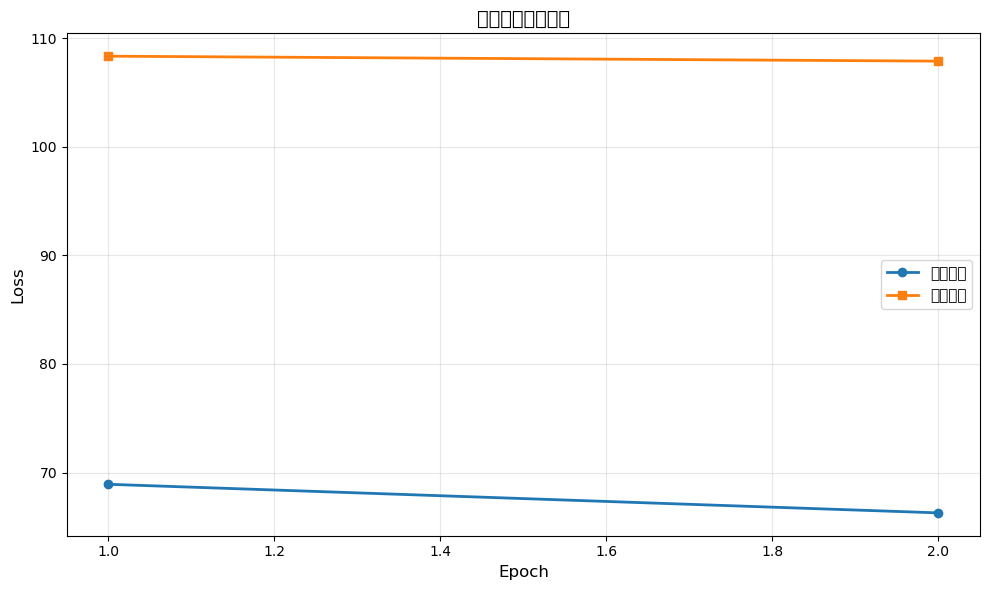

训练曲线已保存


In [91]:
# 绘制训练曲线
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(training_history['epoch'], training_history['train_loss'], 'o-', linewidth=2, label='训练损失', markersize=6)
ax.plot(training_history['epoch'], training_history['val_loss'], 's-', linewidth=2, label='验证损失', markersize=6)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('基线模型训练曲线', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print("训练曲线已保存")

## Part 10: 基线模型评估与保存

In [ ]:
## Part 10: mAP 评估指标计算

# 类别映射
idx_to_class = dataset_train.idx_to_class
num_classes = len(idx_to_class)
print(f"类别映射：{idx_to_class}")
print(f"总类别数：{num_classes}")

def calculate_iou(box1, box2):
    """计算两个 bbox 的 IoU (格式：[cx, cy, w, h])"""
    b1_x1 = box1[0] - box1[2] / 2
    b1_y1 = box1[1] - box1[3] / 2
    b1_x2 = box1[0] + box1[2] / 2
    b1_y2 = box1[1] + box1[3] / 2
    
    b2_x1 = box2[0] - box2[2] / 2
    b2_y1 = box2[1] - box2[3] / 2
    b2_x2 = box2[0] + box2[2] / 2
    b2_y2 = box2[1] + box2[3] / 2
    
    inter_x1 = max(b1_x1, b2_x1)
    inter_y1 = max(b1_y1, b2_y1)
    inter_x2 = min(b1_x2, b2_x2)
    inter_y2 = min(b1_y2, b2_y2)
    
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    b1_area = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    b2_area = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)
    union_area = b1_area + b2_area - inter_area
    
    return inter_area / (union_area + 1e-6) if union_area > 0 else 0

def evaluate_map(predictions, targets, idx_to_class, iou_threshold=0.5):
    """
    计算 mAP@0.5
    predictions: (B, 3, 5+C, H*W) - bbox 已通过 sigmoid
    targets: (B, max_targets, 5)
    只取 top-K 最高置信度的预测，避免遍历全部 grid cell
    """
    num_classes = len(idx_to_class)
    all_pred_boxes = []
    all_pred_scores = []
    all_pred_classes = []
    all_gt_boxes = []
    all_gt_classes = []
    
    for b in range(predictions.size(0)):
        pred = predictions[b]  # (3, 5+C, H*W)
        
        # 收集所有预测：向量化操作
        for anchor_idx in range(3):
            pred_anchor = pred[anchor_idx]
            pred_bbox = pred_anchor[:4, :]  # (4, H*W)
            pred_conf = pred_anchor[4, :]   # (H*W,)
            pred_cls_scores = pred_anchor[5:, :]  # (C, H*W)
            
            # 取每个位置的类别置信度
            cls_pred = torch.argmax(pred_cls_scores, dim=0)  # (H*W,)
            cls_conf, _ = torch.max(pred_cls_scores, dim=0)  # (H*W,)
            
            # 综合得分
            scores = pred_conf * cls_conf
            
            # 只保留高置信度预测 (top-K per image)
            top_k = min(300, len(scores))
            top_indices = torch.topk(scores, top_k).indices
            
            for idx in top_indices:
                conf = scores[idx].item()
                if conf < 0.1:
                    continue
                
                cx = pred_bbox[0, idx].item()
                cy = pred_bbox[1, idx].item()
                w = pred_bbox[2, idx].item()
                h = pred_bbox[3, idx].item()
                
                all_pred_boxes.append([cx, cy, w, h])
                all_pred_scores.append(conf)
                all_pred_classes.append(cls_pred[idx].item())
        
        # 收集 GT
        target_b = targets[b]
        valid_mask = target_b[:, 0] >= 0
        valid_targets = target_b[valid_mask]
        
        for gt in valid_targets:
            cls_id = int(gt[0].item())
            xmin, ymin, xmax, ymax = gt[1:5].tolist()
            cx = (xmin + xmax) / 2 / 640
            cy = (ymin + ymax) / 2 / 640
            w = (xmax - xmin) / 640
            h = (ymax - ymin) / 640
            all_gt_boxes.append([cx, cy, w, h])
            all_gt_classes.append(cls_id)
    
    if len(all_pred_boxes) == 0 or len(all_gt_boxes) == 0:
        return 0.0, [0.0] * num_classes
    
    # 计算每个类别的 AP
    ap_scores = []
    for cls in range(num_classes):
        cls_pred_boxes = [all_pred_boxes[i] for i in range(len(all_pred_boxes)) if all_pred_classes[i] == cls]
        cls_pred_scores = [all_pred_scores[i] for i in range(len(all_pred_scores)) if all_pred_classes[i] == cls]
        cls_gt_boxes = [all_gt_boxes[i] for i in range(len(all_gt_boxes)) if all_gt_classes[i] == cls]
        
        if len(cls_pred_boxes) == 0 or len(cls_gt_boxes) == 0:
            ap_scores.append(0.0)
            continue
        
        sorted_indices = sorted(range(len(cls_pred_scores)), key=lambda i: cls_pred_scores[i], reverse=True)
        
        tp = np.zeros(len(sorted_indices))
        fp = np.zeros(len(sorted_indices))
        gt_matched = [False] * len(cls_gt_boxes)
        
        for i, idx in enumerate(sorted_indices):
            pred_box = cls_pred_boxes[idx]
            best_iou = 0
            best_gt_idx = -1
            
            for j, gt_box in enumerate(cls_gt_boxes):
                if not gt_matched[j]:
                    iou = calculate_iou(pred_box, gt_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = j
            
            if best_iou >= iou_threshold:
                tp[i] = 1
                gt_matched[best_gt_idx] = True
            else:
                fp[i] = 1
        
        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        precision = cum_tp / (cum_tp + cum_fp + 1e-6)
        recall = cum_tp / (len(cls_gt_boxes) + 1e-6)
        
        ap = 0.0
        for t in np.linspace(0, 1, 11):
            if np.sum(recall >= t) > 0:
                p = np.max(precision[recall >= t])
                ap += p / 11
        ap_scores.append(ap)
    
    mAP = np.mean(ap_scores) if ap_scores else 0.0
    return mAP, ap_scores

print("✓ mAP 评估函数定义完成")

# 在验证集上评估 mAP
print("\n" + "="*60)
print("验证集 mAP 评估 (IoU=0.5)")
print("="*60)

model.eval()
all_mAP = []
all_ap_per_class = []

with torch.no_grad():
    for batch_idx, batch in enumerate(val_loader):
        images = batch['image'].to(device)
        targets = batch['targets'].to(device)
        predictions = model(images)
        
        mAP, ap_per_class = evaluate_map(predictions, targets, idx_to_class, iou_threshold=0.5)
        all_mAP.append(mAP)
        all_ap_per_class.append(ap_per_class)
        
        if (batch_idx + 1) % 50 == 0:
            print(f"Processed {batch_idx + 1}/{len(val_loader)} batches")

avg_mAP = np.mean(all_mAP)
avg_ap_per_class = np.mean(all_ap_per_class, axis=0)

print(f"\n平均 mAP@0.5: {avg_mAP:.4f}")
print(f"\n各类别 AP:")
for i, (cls_name, ap) in enumerate(zip(idx_to_class.keys(), avg_ap_per_class)):
    print(f"  - {cls_name}: {ap:.4f}")

# 绘制 AP 对比图
fig, ax = plt.subplots(figsize=(12, 5))
classes = list(idx_to_class.keys())
ax.bar(classes, avg_ap_per_class, color='steelblue', alpha=0.7)
ax.set_ylabel('AP@0.5', fontsize=12)
ax.set_title('各类别平均精度 (AP@0.5)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(avg_ap_per_class):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'class_ap_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nAP 对比图已保存至：figures/class_ap_comparison.png")


In [92]:
# 评估指标统计
print("\n" + "="*50)
print("基线模型性能总结")
print("="*50)

print(f"\n模型架构: LightweightDetectionModel")
print(f"  - Backbone: ResNet18")
print(f"  - 输入通道: 6 (RGB + Thermal)")
print(f"  - 输出类别: {num_classes}")
print(f"  - 总参数数: {total_params:,.0f}")

print(f"\n训练配置:")
print(f"  - 优化器: Adam (lr=1e-4)")
print(f"  - 批大小: {batch_size}")
print(f"  - Epoch: {num_epochs}")
print(f"  - 总训练迭代: {len(train_loader) * num_epochs}")

print(f"\n训练结果:")
print(f"  - 初始训练损失: {training_history['train_loss'][0]:.4f}")
print(f"  - 最终训练损失: {training_history['train_loss'][-1]:.4f}")
print(f"  - 初始验证损失: {training_history['val_loss'][0]:.4f}")
print(f"  - 最终验证损失: {training_history['val_loss'][-1]:.4f}")

print(f"\n损失改进:")
train_improvement = (training_history['train_loss'][0] - training_history['train_loss'][-1]) / training_history['train_loss'][0] * 100
val_improvement = (training_history['val_loss'][0] - training_history['val_loss'][-1]) / training_history['val_loss'][0] * 100
print(f"  - 训练损失改进: {train_improvement:.2f}%")
print(f"  - 验证损失改进: {val_improvement:.2f}%")

print("\n" + "="*50)


基线模型性能总结

模型架构: LightweightDetectionModel
  - Backbone: ResNet18
  - 输入通道: 6 (RGB + Thermal)
  - 输出类别: 9
  - 总参数数: 12,966,698

训练配置:
  - 优化器: Adam (lr=1e-4)
  - 批大小: 8
  - Epoch: 3
  - 总训练迭代: 6744

训练结果:
  - 初始训练损失: 68.9153
  - 最终训练损失: 66.2806
  - 初始验证损失: 108.3631
  - 最终验证损失: 107.9048

损失改进:
  - 训练损失改进: 3.82%
  - 验证损失改进: 0.42%



In [93]:
# 保存模型
model_save_path = str(FIGURES_DIR / 'baseline_model.pth')
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': num_epochs,
    'model_config': {
        'num_classes': num_classes,
        'in_channels': in_channels
    },
    'training_history': training_history
}

torch.save(checkpoint, model_save_path)
print(f"✓ 模型已保存: {model_save_path}")
print(f"  文件大小: {os.path.getsize(model_save_path) / (1024**2):.2f} MB")

✓ 模型已保存: /home/tyr/ultralytics/figures/baseline_model.pth
  文件大小: 148.53 MB


In [ ]:
# 推理可视化：绘制检测框
import matplotlib.patches as patches

def draw_detections(img_path, predictions, idx_to_class, conf_threshold=0.3):
    """
    可视化检测结果
    predictions: (B, 3, 5+C, H*W)
    """
    img = Image.open(img_path).convert('RGB')
    img_np = np.array(img)
    img_h, img_w = img_np.shape[:2]
    
    # predictions 形状：(B, 3, 5+C, H*W)
    pred = predictions[0]  # (3, 5+C, H*W)
    num_anchors = pred.size(0)
    num_classes = len(idx_to_class)
    
    detections = []
    
    for anchor_idx in range(num_anchors):
        pred_anchor = pred[anchor_idx]  # (5+C, H*W)
        pred_bbox = pred_anchor[:4, :]  # (4, H*W) - (cx, cy, w, h)
        pred_conf = pred_anchor[4, :]   # (H*W,)
        pred_cls = pred_anchor[5:, :]   # (C, H*W)
        
        hw = pred_conf.size(0)
        h_feat = w_feat = int(hw ** 0.5)
        
        for idx in range(hw):
            conf = pred_conf[idx].item()
            if conf < conf_threshold:
                continue
            
            cls_scores = pred_cls[:, idx]  # (C,)
            cls_pred = torch.argmax(cls_scores).item()
            cls_conf = torch.max(cls_scores).item()
            
            cx = pred_bbox[0, idx].item()
            cy = pred_bbox[1, idx].item()
            w = pred_bbox[2, idx].item()
            h = pred_bbox[3, idx].item()
            
            # 过滤无效预测（sigmoid 后应在 (0,1) 范围内，但 w/h 可能极小）
            if cx <= 0 or cy <= 0 or w <= 0 or h <= 0:
                continue
            if cx > 1 or cy > 1 or w > 1 or h > 1:
                continue
            if w < 0.001 or h < 0.001:  # 太小的框
                continue
            
            # 转换为像素坐标
            x1 = (cx - w / 2) * img_w
            y1 = (cy - h / 2) * img_h
            x2 = (cx + w / 2) * img_w
            y2 = (cy + h / 2) * img_h
            
            detections.append({
                'bbox': [x1, y1, x2 - x1, y2 - y1],
                'class': idx_to_class.get(cls_pred, f'cls_{cls_pred}'),
                'conf': conf * cls_conf
            })
    
    # 按置信度排序
    detections.sort(key=lambda x: x['conf'], reverse=True)
    
    # 绘图
    fig, ax = plt.subplots(1, figsize=(12, 10))
    ax.imshow(img_np)
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(idx_to_class) + 1))
    class_to_color = {cls: colors[i % len(colors)] for i, cls in enumerate(idx_to_class.keys())}
    
    for det in detections[:20]:  # 最多显示 20 个
        x, y, w, h = det['bbox']
        rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                  edgecolor=class_to_color.get(det['class'], 'red'),
                                  facecolor='none')
        ax.add_patch(rect)
        
        label = f"{det['class']}: {det['conf']:.2f}"
        ax.text(x, y - 5, label, fontsize=9,
                bbox=dict(boxstyle='round', facecolor=class_to_color.get(det['class'], 'red'),
                         alpha=0.7, edgecolor='none'))
    
    ax.set_title(f'Detection Results (Conf > {conf_threshold})', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / 'inference_demo.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    return detections

print("✓ 推理可视化函数定义完成")

# 执行推理可视化
print("\n推理示例：真实图片检测")
print("="*60)

model.eval()

with torch.no_grad():
    sample_batch = next(iter(val_loader))
    images = sample_batch['image'].to(device)
    img_paths = sample_batch['image_path']
    
    predictions = model(images)
    
    print(f"输入形状：{images.shape}")
    print(f"输出形状：{predictions.shape}")
    print(f"\n选取图片：{img_paths[0]}")
    
    # 可视化检测结果
    detections = draw_detections(img_paths[0], predictions.cpu(), dataset_train.idx_to_class, conf_threshold=0.25)
    
    print(f"\n检测到 {len(detections)} 个目标 (置信度 > 0.25)")
    print("前 5 个检测结果:")
    for i, det in enumerate(detections[:5]):
        print(f"  {i+1}. {det['class']}: {det['conf']:.4f}, bbox={det['bbox']}")

print("\n推理结果已保存至：figures/inference_demo.png")


